## 1. Import Libraries and Load Data

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load the merged dataset
df = pd.read_csv('../results/fires_merged_all_features.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFeatures: {df.columns.tolist()}")
print(f"\nTarget distribution:")
print(df['class'].value_counts())
print(f"\nMissing values: {df.isnull().sum().sum()}")

Dataset shape: (6933, 42)

Features: ['longitude', 'latitude', 'class', 'prec_winter', 'tmax_winter', 'tmin_winter', 'prec_spring', 'tmax_spring', 'tmin_spring', 'prec_summer', 'tmax_summer', 'tmin_summer', 'prec_autumn', 'tmax_autumn', 'tmin_autumn', 'elevation', 'slope', 'aspect', 'roughness', 'soil_unit_id', 'COARSE', 'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA', 'TEXTURE_SOTER', 'BULK', 'REF_BULK', 'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY', 'CEC_EFF', 'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM', 'ELEC_COND']

Target distribution:
class
1    3824
0    3109
Name: count, dtype: int64

Missing values: 0


In [3]:
# Display basic statistics
df.describe()

,longitude,latitude,class,prec_winter,tmax_winter,tmin_winter,prec_spring,tmax_spring,tmin_spring,prec_summer,tmax_summer,tmin_summer,prec_autumn,tmax_autumn,tmin_autumn,elevation,slope,aspect,roughness,soil_unit_id,COARSE,SAND,SILT,CLAY,TEXTURE_USDA,BULK,REF_BULK,ORG_CARBON,PH_WATER,TOTAL_N,CN_RATIO,CEC_SOIL,CEC_CLAY,CEC_EFF,TEB,BSAT,ALUM_SAT,ESP,TCARBON_EQ,GYPSUM,ELEC_COND
count,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000,6933.000000
mean,4.884851,35.458504,0.551565,0.102346,0.024317,0.151713,0.129302,0.024767,0.023091,0.140944,0.039621,0.011313,0.119116,0.024647,0.013655,0.100683,0.065959,0.087471,0.069484,8119.011539,-0.400956,-0.393856,0.322544,0.454846,-0.516967,0.451947,0.283040,-0.420206,0.918610,-0.369204,-0.668696,0.209237,0.250988,0.773808,0.882044,0.791195,-0.353700,0.244739,1.088035,0.335205,0.310663
std,3.608096,1.138798,0.497370,0.989478,1.045032,0.910986,0.956287,1.046179,1.045216,0.940644,1.041537,1.047246,0.968562,1.045907,1.044767,0.997417,1.027981,1.010661,1.025494,12531.370655,0.656381,0.697262,0.602697,0.930588,0.938407,0.552841,0.814952,0.582473,0.721082,0.470384,0.871580,0.642498,0.671781,0.868537,0.871532,0.380991,0.254675,0.963105,1.305608,0.924375,0.835189
min,-2.181140,33.016400,0.000000,-1.044808,-3.814849,-2.088837,-1.302133,-3.382527,-3.487458,-1.404653,-2.454975,-3.833635,-1.212442,-3.684878,-3.378425,-1.047109,-0.639575,-1.761676,-0.673754,36.000000,-2.160848,-2.494089,-2.402592,-2.161582,-2.268551,-1.723473,-1.589213,-1.386431,-1.370559,-1.753464,-1.991356,-1.948901,-2.689560,-2.009049,-1.759455,-2.148575,-1.790432,-1.146155,-1.741984,-0.756240,-1.463056
25%,2.021050,34.598080,0.000000,-0.720898,-0.816513,-0.588075,-0.631903,-0.544660,-0.715064,-0.709061,-0.655505,-0.471969,-0.554400,-0.671520,-0.763902,-0.825169,-0.558306,-0.718200,-0.572870,1129.000000,-0.788323,-1.094008,0.003192,-0.319134,-1.459993,0.059544,-0.503939,-0.854876,0.785460,-0.765359,-1.329358,-0.156700,-0.042116,-0.037841,-0.146117,0.715764,-0.361163,-0.131095,-0.605405,-0.541156,0.264563
50%,5.179720,35.798190,1.000000,-0.102992,-0.039672,0.366433,-0.020565,-0.210793,-0.035632,0.268470,-0.310659,-0.140537,-0.212943,-0.026871,0.065094,-0.204210,-0.402498,0.065347,-0.408283,1526.000000,-0.788323,-0.393968,0.188253,0.075677,0.157122,0.594450,-0.051741,-0.616759,1.234630,-0.234710,-0.667360,0.201740,0.157691,1.381428,1.393887,0.984295,-0.361163,-0.131095,1.622291,-0.110987,0.264563
75%,7.803120,36.495780,1.000000,0.845160,0.975673,0.958688,0.901607,0.456940,0.604752,0.866782,0.485622,0.295059,0.811188,0.595290,0.591187,0.976321,0.259713,0.934211,0.332991,1964.000000,0.172444,0.306072,0.835964,1.128504,0.157122,0.861902,0.852654,-0.293256,1.414298,-0.179816,-0.667360,0.380960,0.906968,1.381428,1.393887,1.029051,-0.361163,0.883965,1.963265,1.502144,0.264563
max,11.110350,37.323460,1.000000,3.088266,2.324924,2.229448,2.937571,3.105110,3.049144,2.808930,2.830577,3.259006,2.787216,3.083934,2.727443,3.505017,7.716784,1.889797,7.632295,32044.000000,3.466503,1.628370,1.391145,2.312936,1.369959,2.110015,2.661443,2.748149,1.773635,2.327043,2.642632,2.890041,1.706197,2.800697,3.007224,1.029051,3.069082,3.929144,3.304429,2.792650,1.992183


## 2. Feature Extraction

Create new features from existing ones to capture domain knowledge and improve predictive power.

### 2.1 Climate-Based Features

In [4]:
# Create a copy for feature engineering
df_engineered = df.copy()

# Temperature features
# Annual temperature range (max - min across all seasons)
temp_max_cols = ['tmax_winter', 'tmax_spring', 'tmax_summer', 'tmax_autumn']
temp_min_cols = ['tmin_winter', 'tmin_spring', 'tmin_summer', 'tmin_autumn']

df_engineered['annual_temp_range'] = df_engineered[temp_max_cols].max(axis=1) - df_engineered[temp_min_cols].min(axis=1)
df_engineered['avg_tmax'] = df_engineered[temp_max_cols].mean(axis=1)
df_engineered['avg_tmin'] = df_engineered[temp_min_cols].mean(axis=1)
df_engineered['diurnal_temp_range'] = df_engineered['avg_tmax'] - df_engineered['avg_tmin']

# Precipitation features
prec_cols = ['prec_winter', 'prec_spring', 'prec_summer', 'prec_autumn']
df_engineered['total_annual_precip'] = df_engineered[prec_cols].sum(axis=1)
df_engineered['summer_precip_ratio'] = df_engineered['prec_summer'] / (df_engineered['total_annual_precip'] + 1e-6)
df_engineered['precip_variability'] = df_engineered[prec_cols].std(axis=1)

# Fire season indicators (summer is typically high fire risk)
df_engineered['summer_heat_index'] = df_engineered['tmax_summer'] - df_engineered['prec_summer']
df_engineered['drought_index'] = df_engineered['tmax_summer'] / (df_engineered['prec_summer'] + 1)

print(f"Created {9} climate-based features")
print(f"New shape: {df_engineered.shape}")

Created 9 climate-based features
New shape: (6933, 51)


### 2.2 Topography-Based Features

In [5]:
# Terrain ruggedness and fire accessibility
df_engineered['terrain_complexity'] = df_engineered['slope'] * df_engineered['roughness']
df_engineered['elevation_slope_interaction'] = df_engineered['elevation'] * df_engineered['slope']

# Aspect categories (convert continuous aspect to cardinal directions)
# North: 0°-45°, 315°-360° (coded as 0)
# East: 45°-135° (coded as 1)
# South: 135°-225° (coded as 2)
# West: 225°-315° (coded as 3)
def aspect_to_cardinal(aspect):
    if -1 <= aspect <= 1:  # Normalized aspect values
        # Convert normalized aspect back to degrees (assuming -1 to 1 maps to 0 to 360)
        aspect_deg = (aspect + 1) * 180
        if (aspect_deg >= 0 and aspect_deg < 45) or (aspect_deg >= 315 and aspect_deg <= 360):
            return 0  # North
        elif aspect_deg >= 45 and aspect_deg < 135:
            return 1  # East
        elif aspect_deg >= 135 and aspect_deg < 225:
            return 2  # South
        else:
            return 3  # West
    return 0

df_engineered['aspect_cardinal'] = df_engineered['aspect'].apply(aspect_to_cardinal)

# South-facing slopes receive more solar radiation (higher fire risk)
df_engineered['is_south_facing'] = (df_engineered['aspect_cardinal'] == 2).astype(int)

print(f"Created {4} topography-based features")
print(f"New shape: {df_engineered.shape}")

Created 4 topography-based features
New shape: (6933, 55)


### 2.3 Soil-Based Features

In [6]:
# Soil composition ratios
df_engineered['sand_clay_ratio'] = df_engineered['SAND'] / (df_engineered['CLAY'] + 1e-6)
df_engineered['fine_fraction'] = df_engineered['SILT'] + df_engineered['CLAY']

# Soil fertility and moisture indicators
df_engineered['fertility_index'] = df_engineered['ORG_CARBON'] * df_engineered['TOTAL_N']
df_engineered['moisture_retention'] = df_engineered['CLAY'] * df_engineered['ORG_CARBON']

# Chemical properties
df_engineered['ph_carbon_interaction'] = df_engineered['PH_WATER'] * df_engineered['ORG_CARBON']
df_engineered['nutrient_availability'] = df_engineered['CEC_SOIL'] * df_engineered['BSAT']

print(f"Created {6} soil-based features")
print(f"New shape: {df_engineered.shape}")

Created 6 soil-based features
New shape: (6933, 61)


### 2.4 Spatial Features

In [7]:
# Geographic regions (Algeria vs Tunisia based on longitude)
# Algeria: longitude < 10, Tunisia: longitude >= 10 (approximately)
df_engineered['country'] = (df_engineered['longitude'] >= 10).astype(int)  # 0: Algeria, 1: Tunisia

# Distance from coast (using latitude as proxy - lower latitude = closer to coast)
df_engineered['coastal_proximity'] = 37 - df_engineered['latitude']  # Max latitude is ~37

# Coordinate clustering (spatial density)
df_engineered['lat_long_interaction'] = df_engineered['latitude'] * df_engineered['longitude']

print(f"Created {3} spatial features")
print(f"New shape: {df_engineered.shape}")

Created 3 spatial features
New shape: (6933, 64)


In [8]:
# Summary of feature extraction
original_features = df.shape[1]
new_features = df_engineered.shape[1] - original_features

print(f"\n{'='*60}")
print(f"Feature Extraction Summary")
print(f"{'='*60}")
print(f"Original features: {original_features}")
print(f"New features created: {new_features}")
print(f"Total features: {df_engineered.shape[1]}")
print(f"\nNew features:")
new_feature_names = df_engineered.columns[original_features:].tolist()
for i, feat in enumerate(new_feature_names, 1):
    print(f"  {i}. {feat}")


Feature Extraction Summary
Original features: 42
New features created: 22
Total features: 64

New features:
  1. annual_temp_range
  2. avg_tmax
  3. avg_tmin
  4. diurnal_temp_range
  5. total_annual_precip
  6. summer_precip_ratio
  7. precip_variability
  8. summer_heat_index
  9. drought_index
  10. terrain_complexity
  11. elevation_slope_interaction
  12. aspect_cardinal
  13. is_south_facing
  14. sand_clay_ratio
  15. fine_fraction
  16. fertility_index
  17. moisture_retention
  18. ph_carbon_interaction
  19. nutrient_availability
  20. country
  21. coastal_proximity
  22. lat_long_interaction


## 3. Feature Selection

Identify and select the most relevant features using multiple techniques.

### 3.1 Correlation Analysis

In [ ]:
# Remove non-feature columns
X = df_engineered.drop(['class', 'longitude', 'latitude'], axis=1)
y = df_engineered['class']

print("="*80)
print("CATEGORICAL FEATURE ENCODING")
print("="*80)

# Identify categorical columns
# Note: TEXTURE_USDA is already numerical (normalized), only TEXTURE_SOTER is truly categorical
categorical_cols = ['TEXTURE_SOTER']  # Only this one is truly categorical

print(f"\nIdentified categorical feature: {categorical_cols}")
print(f"  TEXTURE_SOTER unique values: {X['TEXTURE_SOTER'].unique()}")
print(f"  Distribution:")
for val, count in X['TEXTURE_SOTER'].value_counts().items():
    print(f"    {val}: {count} ({count/len(X)*100:.1f}%)")

# Apply One-Hot Encoding to TEXTURE_SOTER
print(f"\n🔧 Applying One-Hot Encoding to {categorical_cols[0]}...")
print(f"   Method: Create binary columns for each category")
print(f"   Strategy: Drop first category (alphabetically) to avoid multicollinearity")

X_encoded = pd.get_dummies(
    X, 
    columns=categorical_cols,
    drop_first=True,  # Drop first category alphabetically (C in this case)
    prefix='TEXTURE_SOTER'
)

print(f"\n✅ One-Hot Encoding Complete!")
print(f"   Before: {X.shape[1]} features")
print(f"   After: {X_encoded.shape[1]} features")
print(f"   New binary columns created:")

# Show the new one-hot encoded columns
one_hot_cols = [col for col in X_encoded.columns if col.startswith('TEXTURE_SOTER_')]
for col in one_hot_cols:
    print(f"     - {col} (1 when texture is {col.split('_')[-1]}, 0 otherwise)")

print(f"\n   Baseline category: TEXTURE_SOTER_C (when all binary columns = 0)")
print(f"   Note: drop_first=True drops the first category alphabetically (C)")
print(f"   ✓ These binary columns will now compete with numerical features!")

# Update X to use encoded version
X = X_encoded

# All columns are now numerical (including one-hot encoded)
numerical_cols = X.columns.tolist()

print(f"\n{'='*80}")
print(f"FEATURE SET READY FOR SELECTION")
print(f"{'='*80}")
print(f"Total features: {X.shape[1]}")
print(f"All features are now numerical (including one-hot encoded)")
print(f"  - Original numerical: {X.shape[1] - len(one_hot_cols)}")
print(f"  - One-hot encoded: {len(one_hot_cols)}")

CATEGORICAL FEATURE ENCODING

Identified categorical feature: ['TEXTURE_SOTER']
  TEXTURE_SOTER unique values: ['M' 'F' 'C']
  Distribution:
    M: 5929 (85.5%)
    F: 831 (12.0%)
    C: 173 (2.5%)

🔧 Applying One-Hot Encoding to TEXTURE_SOTER...
   Method: Create binary columns for each category
   Strategy: Drop first category to avoid multicollinearity

✅ One-Hot Encoding Complete!
   Before: 61 features
   After: 62 features
   New binary columns created:
     - TEXTURE_SOTER_F (1 when texture is F, 0 otherwise)
     - TEXTURE_SOTER_M (1 when texture is M, 0 otherwise)

   Baseline category: TEXTURE_SOTER_M (when all binary columns = 0)
   ✓ These binary columns will now compete with numerical features!

FEATURE SET READY FOR SELECTION
Total features: 62
All features are now numerical (including one-hot encoded)
  - Original numerical: 60
  - One-hot encoded: 2


In [10]:
print("="*80)
print("STEP 1: REMOVE MULTICOLLINEARITY (Feature-to-Feature Correlation)")
print("="*80)

# Create numerical_X from the encoded features (all features are now numerical)
numerical_X = X.copy()

# Calculate correlation matrix for numerical features
correlation_matrix = numerical_X.corr().abs()

# Calculate correlation with target for later use
target_corr = numerical_X.corrwith(y).abs()

print(f"\nTotal numerical features: {len(numerical_cols)}")
print(f"Analyzing feature-to-feature correlations...\n")

# Find pairs of highly correlated features
threshold_multicollinearity = 0.90
to_remove = set()
pairs_found = []

# Iterate through correlation matrix (upper triangle only)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        feat_i = correlation_matrix.columns[i]
        feat_j = correlation_matrix.columns[j]
        
        # If features are highly correlated
        if correlation_matrix.iloc[i, j] > threshold_multicollinearity:
            corr_value = correlation_matrix.iloc[i, j]
            target_corr_i = target_corr[feat_i]
            target_corr_j = target_corr[feat_j]
            
            # Keep the feature with higher target correlation
            if target_corr_i >= target_corr_j:
                to_remove.add(feat_j)
                kept_feature = feat_i
                removed_feature = feat_j
                kept_corr = target_corr_i
                removed_corr = target_corr_j
            else:
                to_remove.add(feat_i)
                kept_feature = feat_j
                removed_feature = feat_i
                kept_corr = target_corr_j
                removed_corr = target_corr_i
            
            pairs_found.append({
                'feature_1': feat_i,
                'feature_2': feat_j,
                'pair_correlation': corr_value,
                'kept': kept_feature,
                'removed': removed_feature,
                'kept_target_corr': kept_corr,
                'removed_target_corr': removed_corr
            })

# Display pairs information
if pairs_found:
    print(f"Found {len(pairs_found)} highly correlated pairs (correlation > {threshold_multicollinearity}):\n")
    for idx, pair in enumerate(pairs_found, 1):
        print(f"  Pair {idx}: '{pair['feature_1']}' ↔ '{pair['feature_2']}'")
        print(f"    Feature-to-Feature correlation: {pair['pair_correlation']:.3f}")
        print(f"    ✓ Kept '{pair['kept']}' (target corr: {pair['kept_target_corr']:.4f})")
        print(f"    ✗ Removed '{pair['removed']}' (target corr: {pair['removed_target_corr']:.4f})")
        print()
else:
    print(f"No highly correlated pairs found (threshold: {threshold_multicollinearity})")

print(f"{'='*80}")
print(f"✅ Multicollinearity Removal Complete")
print(f"{'='*80}")
print(f"Features to remove: {len(to_remove)}")
print(f"Features remaining: {len(numerical_cols) - len(to_remove)}")

# Remove redundant features
numerical_X_reduced = numerical_X.drop(columns=list(to_remove))
print(f"\nReduced feature set shape: {numerical_X_reduced.shape}")

STEP 1: REMOVE MULTICOLLINEARITY (Feature-to-Feature Correlation)

Total numerical features: 62
Analyzing feature-to-feature correlations...

Found 16 highly correlated pairs (correlation > 0.9):

  Pair 1: 'prec_winter' ↔ 'prec_spring'
    Feature-to-Feature correlation: 0.914
    ✓ Kept 'prec_winter' (target corr: 0.3904)
    ✗ Removed 'prec_spring' (target corr: 0.3330)

  Pair 2: 'prec_winter' ↔ 'prec_autumn'
    Feature-to-Feature correlation: 0.914
    ✓ Kept 'prec_winter' (target corr: 0.3904)
    ✗ Removed 'prec_autumn' (target corr: 0.3674)

  Pair 3: 'prec_winter' ↔ 'total_annual_precip'
    Feature-to-Feature correlation: 0.923
    ✓ Kept 'prec_winter' (target corr: 0.3904)
    ✗ Removed 'total_annual_precip' (target corr: 0.3124)

  Pair 4: 'tmax_winter' ↔ 'tmax_autumn'
    Feature-to-Feature correlation: 0.918
    ✓ Kept 'tmax_winter' (target corr: 0.1559)
    ✗ Removed 'tmax_autumn' (target corr: 0.0050)

  Pair 5: 'prec_spring' ↔ 'prec_autumn'
    Feature-to-Feature corr

In [11]:
print("="*80)
print("STEP 2: SELECT TOP FEATURES BY TARGET CORRELATION")
print("="*80)

# Calculate correlation with target for remaining features
target_corr_reduced = numerical_X_reduced.corrwith(y).abs().sort_values(ascending=False)

print(f"\nFeatures after multicollinearity removal: {len(target_corr_reduced)}")
print(f"\nTop 30 features by target correlation:\n")

for i, (feat, corr) in enumerate(target_corr_reduced.head(30).items(), 1):
    print(f"  {i:2d}. {feat:45s} | r = {corr:.4f}")

# Select top 30 features by target correlation
top_k_initial = 30
selected_by_target_corr = target_corr_reduced.head(top_k_initial).index.tolist()

print(f"\n{'='*80}")
print(f"✅ Target Correlation Selection Complete")
print(f"{'='*80}")
print(f"Selected top {top_k_initial} features with highest target correlation")
print(f"Correlation range: {target_corr_reduced.iloc[0]:.4f} to {target_corr_reduced.iloc[top_k_initial-1]:.4f}")

# Update numerical_X to only include selected features
numerical_X_selected = numerical_X_reduced[selected_by_target_corr]
print(f"\nSelected feature set shape: {numerical_X_selected.shape}")

STEP 2: SELECT TOP FEATURES BY TARGET CORRELATION

Features after multicollinearity removal: 52

Top 30 features by target correlation:

   1. coastal_proximity                             | r = 0.4919
   2. ph_carbon_interaction                         | r = 0.3956
   3. prec_winter                                   | r = 0.3904
   4. diurnal_temp_range                            | r = 0.3659
   5. ORG_CARBON                                    | r = 0.3521
   6. annual_temp_range                             | r = 0.3469
   7. TOTAL_N                                       | r = 0.3294
   8. tmin_winter                                   | r = 0.3271
   9. SAND                                          | r = 0.3257
  10. tmax_summer                                   | r = 0.3157
  11. elevation                                     | r = 0.3152
  12. CN_RATIO                                      | r = 0.2883
  13. REF_BULK                                      | r = 0.2839
  14. PH_WATER    

### 3.2 Narrow Down to Top 20 Features

Apply additional feature selection methods to refine from 30 to 20 features.

STEP 3: APPLY ADDITIONAL METHODS TO NARROW TO TOP 20

📊 Method 1: ANOVA F-Test
--------------------------------------------------------------------------------

Top 20 features by ANOVA F-Score:

   1. coastal_proximity                             | F-Score =  2212.37
   2. ph_carbon_interaction                         | F-Score =  1286.06
   3. prec_winter                                   | F-Score =  1246.64
   4. diurnal_temp_range                            | F-Score =  1071.50
   5. ORG_CARBON                                    | F-Score =   980.64
   6. annual_temp_range                             | F-Score =   948.10
   7. TOTAL_N                                       | F-Score =   843.83
   8. tmin_winter                                   | F-Score =   830.62
   9. SAND                                          | F-Score =   822.35
  10. tmax_summer                                   | F-Score =   767.29
  11. elevation                                     | F-Score =   764.38
 

<Figure size 1000x800 with 0 Axes>

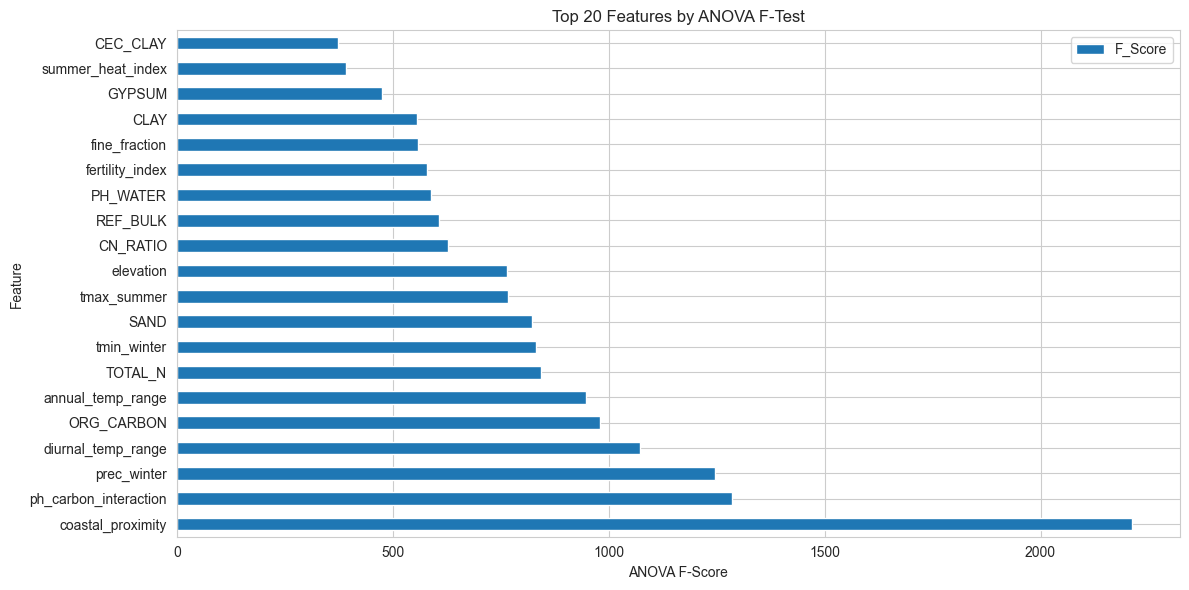

In [12]:
print("="*80)
print("STEP 3: APPLY ADDITIONAL METHODS TO NARROW TO TOP 20")
print("="*80)

print("\n📊 Method 1: ANOVA F-Test")
print("-" * 80)

# ANOVA F-test for the 30 selected features
selector_anova = SelectKBest(f_classif, k='all')
selector_anova.fit(numerical_X_selected, y)

# Get scores
anova_scores = pd.DataFrame({
    'Feature': numerical_X_selected.columns,
    'F_Score': selector_anova.scores_,
    'P_Value': selector_anova.pvalues_
}).sort_values('F_Score', ascending=False)

print("\nTop 20 features by ANOVA F-Score:\n")
for i, row in enumerate(anova_scores.head(20).itertuples(), 1):
    print(f"  {i:2d}. {row.Feature:45s} | F-Score = {row.F_Score:8.2f}")

# Visualize
plt.figure(figsize=(10, 8))
anova_scores.head(20).plot(x='Feature', y='F_Score', kind='barh')
plt.xlabel('ANOVA F-Score')
plt.title('Top 20 Features by ANOVA F-Test')
plt.tight_layout()
plt.show()


📊 Method 2: Mutual Information
--------------------------------------------------------------------------------

Top 20 features by Mutual Information:

   1. prec_winter                                   | MI-Score = 0.3115
   2. annual_temp_range                             | MI-Score = 0.2916
   3. diurnal_temp_range                            | MI-Score = 0.2765
   4. tmin_winter                                   | MI-Score = 0.2710
   5. summer_heat_index                             | MI-Score = 0.2705
   6. tmin_autumn                                   | MI-Score = 0.2670
   7. tmax_summer                                   | MI-Score = 0.2564
   8. coastal_proximity                             | MI-Score = 0.2507
   9. tmax_winter                                   | MI-Score = 0.2337
  10. fertility_index                               | MI-Score = 0.1354
  11. ORG_CARBON                                    | MI-Score = 0.1333
  12. ph_carbon_interaction                         | 

<Figure size 1000x800 with 0 Axes>

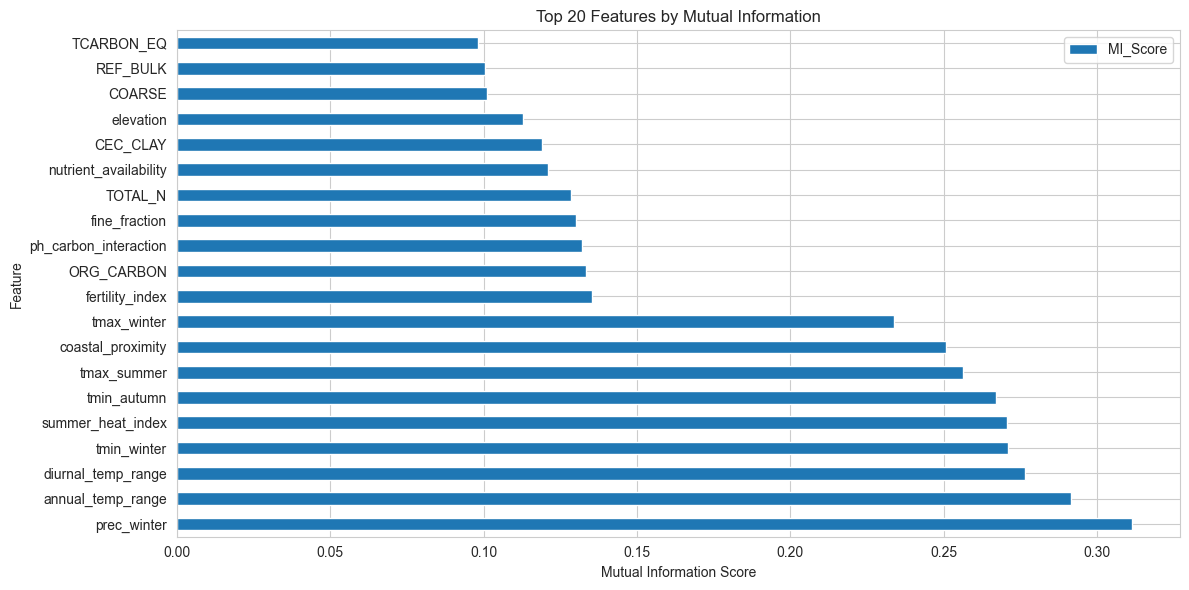

In [13]:
print("\n📊 Method 2: Mutual Information")
print("-" * 80)

# Mutual Information for the 30 selected features
mi_scores = mutual_info_classif(numerical_X_selected, y, random_state=42)
mi_scores_df = pd.DataFrame({
    'Feature': numerical_X_selected.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("\nTop 20 features by Mutual Information:\n")
for i, row in enumerate(mi_scores_df.head(20).itertuples(), 1):
    print(f"  {i:2d}. {row.Feature:45s} | MI-Score = {row.MI_Score:.4f}")

# Visualize
plt.figure(figsize=(10, 8))
mi_scores_df.head(20).plot(x='Feature', y='MI_Score', kind='barh')
plt.xlabel('Mutual Information Score')
plt.title('Top 20 Features by Mutual Information')
plt.tight_layout()
plt.show()

### 3.3 Feature Importance from Random Forest


📊 Method 3: Random Forest Feature Importance
--------------------------------------------------------------------------------

Top 20 features by Random Forest Importance:

   1. coastal_proximity                             | Importance = 0.2101
   2. elevation                                     | Importance = 0.1166
   3. prec_winter                                   | Importance = 0.0877
   4. tmax_summer                                   | Importance = 0.0694
   5. diurnal_temp_range                            | Importance = 0.0693
   6. tmin_winter                                   | Importance = 0.0561
   7. summer_heat_index                             | Importance = 0.0554
   8. annual_temp_range                             | Importance = 0.0533
   9. tmin_autumn                                   | Importance = 0.0532
  10. tmax_winter                                   | Importance = 0.0503
  11. ph_carbon_interaction                         | Importance = 0.0319
  12. ORG_CA

<Figure size 1000x800 with 0 Axes>

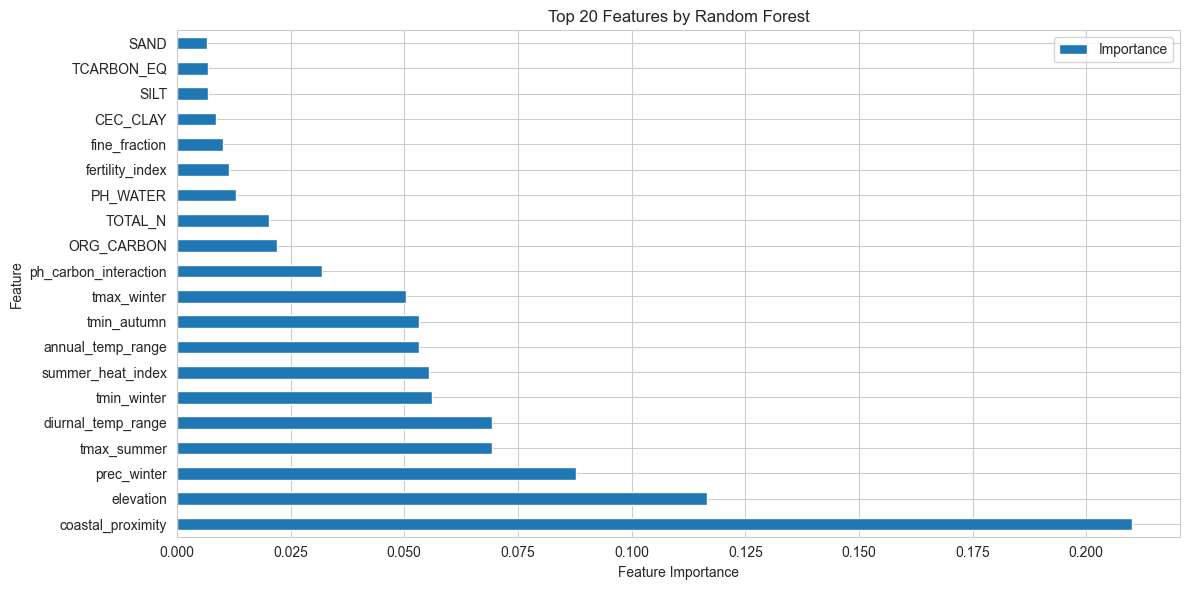

In [14]:
print("\n📊 Method 3: Random Forest Feature Importance")
print("-" * 80)

# Train Random Forest on the 30 selected features
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(numerical_X_selected, y)

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': numerical_X_selected.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 20 features by Random Forest Importance:\n")
for i, row in enumerate(feature_importance.head(20).itertuples(), 1):
    print(f"  {i:2d}. {row.Feature:45s} | Importance = {row.Importance:.4f}")

# Visualize
plt.figure(figsize=(10, 8))
feature_importance.head(20).plot(x='Feature', y='Importance', kind='barh')
plt.xlabel('Feature Importance')
plt.title('Top 20 Features by Random Forest')
plt.tight_layout()
plt.show()

### 3.4 Combine Methods and Select Final Top 20 Features

In [15]:
print("="*80)
print("STEP 4: COMBINE ALL METHODS AND SELECT FINAL TOP 20")
print("="*80)

# Normalize scores to 0-1 range
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Create a comprehensive scoring dataframe for the 30 features
feature_scores = pd.DataFrame({'Feature': numerical_X_selected.columns})

# Add target correlation scores (already computed)
correlation_scores = target_corr_reduced[numerical_X_selected.columns].reset_index()
correlation_scores.columns = ['Feature', 'Correlation']
feature_scores = feature_scores.merge(correlation_scores, on='Feature', how='left')

# Add ANOVA scores
feature_scores = feature_scores.merge(
    anova_scores[['Feature', 'F_Score']],
    on='Feature', how='left'
)

# Add MI scores
feature_scores = feature_scores.merge(
    mi_scores_df,
    on='Feature', how='left'
)

# Add RF importance
feature_scores = feature_scores.merge(
    feature_importance[['Feature', 'Importance']],
    on='Feature', how='left'
)

# Fill NaN values with 0
feature_scores = feature_scores.fillna(0)

# Normalize each score
for col in ['Correlation', 'F_Score', 'MI_Score', 'Importance']:
    if feature_scores[col].max() > 0:
        feature_scores[f'{col}_norm'] = scaler.fit_transform(feature_scores[[col]])
    else:
        feature_scores[f'{col}_norm'] = 0

# Calculate composite score (average of normalized scores)
feature_scores['Composite_Score'] = feature_scores[
    ['Correlation_norm', 'F_Score_norm', 'MI_Score_norm', 'Importance_norm']
].mean(axis=1)

# Sort by composite score
feature_scores = feature_scores.sort_values('Composite_Score', ascending=False)

print("\nTop 20 features by composite score:\n")
print(f"{'Rank':<6} {'Feature':<45} {'Composite':<12} {'Corr':<8} {'F-Score':<10} {'MI':<8} {'RF Imp':<8}")
print("-" * 105)
for i, row in enumerate(feature_scores.head(20).itertuples(), 1):
    print(f"{i:<6} {row.Feature:<45} {row.Composite_Score:.4f}      {row.Correlation:.4f}   {row.F_Score:8.1f}   {row.MI_Score:.4f}   {row.Importance:.4f}")

print(f"\n{'='*80}")
print(f"✅ Final Feature Selection Complete")
print(f"{'='*80}")

STEP 4: COMBINE ALL METHODS AND SELECT FINAL TOP 20

Top 20 features by composite score:

Rank   Feature                                       Composite    Corr     F-Score    MI       RF Imp  
---------------------------------------------------------------------------------------------------------
1      coastal_proximity                             0.9474      0.4919     2212.4   0.2507   0.2101
2      prec_winter                                   0.6669      0.3904     1246.6   0.3115   0.0877
3      diurnal_temp_range                            0.5764      0.3659     1071.5   0.2765   0.0693
4      annual_temp_range                             0.5423      0.3469      948.1   0.2916   0.0533
5      tmin_winter                                   0.4997      0.3271      830.6   0.2710   0.0561
6      tmax_summer                                   0.4873      0.3157      767.3   0.2564   0.0694
7      ph_carbon_interaction                         0.4534      0.3956     1286.1   0.1320   

In [16]:
# Select top 20 features based on composite score
# Note: All features (including one-hot encoded) competed fairly
top_k_final = 20
selected_features = feature_scores['Feature'].head(top_k_final).tolist()

print(f"\n{'='*80}")
print(f"FEATURE SELECTION SUMMARY")
print(f"{'='*80}")
print(f"Original features (before encoding): {len(df_engineered.columns) - 3}")  # Exclude lon, lat, class
print(f"After one-hot encoding: {len(X.columns)}")
print(f"After multicollinearity removal: {len(numerical_X_reduced.columns)}")
print(f"After target correlation selection (top 30): {len(numerical_X_selected.columns)}")
print(f"After composite scoring (final top 20): {len(selected_features)}")
print(f"\nTotal features removed: {len(X.columns) - len(selected_features)}")

# Check if any one-hot encoded features made it to top 20
one_hot_selected = [f for f in selected_features if f.startswith('TEXTURE_SOTER_')]
numerical_selected = [f for f in selected_features if not f.startswith('TEXTURE_SOTER_')]

print(f"\n📋 Final Selected Features ({len(selected_features)}):")
print("-" * 80)
print(f"\nNumerical Features: {len(numerical_selected)}")
for i, feat in enumerate(numerical_selected, 1):
    # Check if it's in top scores
    score_info = feature_scores[feature_scores['Feature'] == feat]
    if not score_info.empty:
        print(f"  {i:2d}. {feat:<45} (Composite Score: {score_info.iloc[0]['Composite_Score']:.4f})")
    else:
        print(f"  {i:2d}. {feat}")

if one_hot_selected:
    print(f"\nOne-Hot Encoded Features: {len(one_hot_selected)}")
    for i, feat in enumerate(one_hot_selected, 1):
        score_info = feature_scores[feature_scores['Feature'] == feat]
        if not score_info.empty:
            print(f"  {i:2d}. {feat:<45} (Composite Score: {score_info.iloc[0]['Composite_Score']:.4f})")
        else:
            print(f"  {i:2d}. {feat}")
    print(f"\n   ✓ One-hot features competed successfully and made it to top 20!")
else:
    print(f"\nOne-Hot Encoded Features: 0")
    print(f"   (None of the one-hot features had high enough predictive power)")

# Create dataset with selected features
X_selected = X[selected_features].copy()
print(f"\n✅ Selected feature set shape: {X_selected.shape}")


FEATURE SELECTION SUMMARY
Original features (before encoding): 61
After one-hot encoding: 62
After multicollinearity removal: 52
After target correlation selection (top 30): 30
After composite scoring (final top 20): 20

Total features removed: 42

📋 Final Selected Features (20):
--------------------------------------------------------------------------------

Numerical Features: 20
   1. coastal_proximity                             (Composite Score: 0.9474)
   2. prec_winter                                   (Composite Score: 0.6669)
   3. diurnal_temp_range                            (Composite Score: 0.5764)
   4. annual_temp_range                             (Composite Score: 0.5423)
   5. tmin_winter                                   (Composite Score: 0.4997)
   6. tmax_summer                                   (Composite Score: 0.4873)
   7. ph_carbon_interaction                         (Composite Score: 0.4534)
   8. elevation                                     (Composite Scor

## 4. Feature Scaling

Normalize numerical features to ensure they have similar scales.

**Note**: Categorical feature (TEXTURE_SOTER) was already one-hot encoded in Section 3, so all features are now numerical and ready for scaling.

In [17]:
# Verify all selected features are numerical
print("="*80)
print("FEATURE TYPE VERIFICATION")
print("="*80)

print(f"\nSelected features ({len(X_selected.columns)}):")
print(f"  Total: {X_selected.shape[1]}")
print(f"  All numerical: {all(X_selected.dtypes != 'object')}")

# Show data types
print(f"\nData types:")
dtype_counts = X_selected.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count} features")

# Check for one-hot encoded features in selected set
one_hot_in_selected = [col for col in X_selected.columns if col.startswith('TEXTURE_SOTER_')]
if one_hot_in_selected:
    print(f"\n✓ One-hot encoded features in final selection:")
    for col in one_hot_in_selected:
        unique_vals = X_selected[col].unique()
        print(f"  {col}: {unique_vals} (binary)")
else:
    print(f"\n✗ No one-hot encoded features in final selection")

print(f"\n✓ All features are numerical and ready for scaling!")
print("="*80)

FEATURE TYPE VERIFICATION

Selected features (20):
  Total: 20
  All numerical: True

Data types:
  float64: 20 features

✗ No one-hot encoded features in final selection

✓ All features are numerical and ready for scaling!


In [18]:
# Check feature distributions before scaling
print("="*80)
print("FEATURE STATISTICS BEFORE SCALING")
print("="*80)

print("\nSample statistics for first 5 features:")
print(X_selected.describe().T[['mean', 'std', 'min', 'max']].head())

# Check one-hot encoded features (should be binary 0/1)
one_hot_in_selected = [col for col in X_selected.columns if col.startswith('TEXTURE_SOTER_')]
if one_hot_in_selected:
    print(f"\nOne-hot encoded features (binary, no scaling needed):")
    for col in one_hot_in_selected:
        print(f"  {col}: min={X_selected[col].min()}, max={X_selected[col].max()}, unique values={X_selected[col].nunique()}")

print("\n✓ Ready for scaling!")
print("="*80)

FEATURE STATISTICS BEFORE SCALING

Sample statistics for first 5 features:
                        mean       std       min       max
coastal_proximity   1.541496  1.138798 -0.323460  3.983600
prec_winter         0.102346  0.989478 -1.044808  3.088266
diurnal_temp_range -0.021605  0.525175 -1.945086  1.320856
annual_temp_range   1.117281  0.819769 -0.752898  3.245648
tmin_winter         0.151713  0.910986 -2.088837  2.229448

✓ Ready for scaling!


### 4.1 Apply StandardScaler

Normalize all features (including one-hot encoded binary features) using Z-score normalization.

In [19]:
# Apply StandardScaler (Z-score normalization)
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_selected),
    columns=X_selected.columns,
    index=X_selected.index
)

print("="*80)
print("FEATURE SCALING COMPLETE")
print("="*80)

print("\nFeature statistics after scaling:\n")
print(X_scaled.describe().T[['mean', 'std', 'min', 'max']].head(10))

print(f"\n{'='*80}")
print(f"Feature Scaling Summary")
print(f"{'='*80}")
print(f"Scaling method: StandardScaler (Z-score normalization)")
print(f"Features scaled: {X_scaled.shape[1]}")
print(f"All features now have mean ≈ 0 and std ≈ 1")

# Note about one-hot encoded features
one_hot_in_scaled = [col for col in X_scaled.columns if col.startswith('TEXTURE_SOTER_')]
if one_hot_in_scaled:
    print(f"\nNote: One-hot encoded features also scaled:")
    for col in one_hot_in_scaled:
        print(f"  {col}: mean={X_scaled[col].mean():.4f}, std={X_scaled[col].std():.4f}")
    print(f"  (Binary 0/1 values normalized to z-scores for consistency)")

print("="*80)

FEATURE SCALING COMPLETE

Feature statistics after scaling:

                               mean       std       min       max
coastal_proximity     -1.229845e-17  1.000072 -1.637771  2.144613
prec_winter           -1.024871e-18  1.000072 -1.159436  3.017891
diurnal_temp_range     2.562176e-18  1.000072 -3.662819  2.556403
annual_temp_range     -2.254715e-16  1.000072 -2.281513  2.596487
tmin_winter            3.689534e-17  1.000072 -2.459656  2.280919
tmax_summer           -3.023368e-17  1.000072 -2.395283  2.679843
ph_carbon_interaction  1.373327e-16  1.000072 -2.596949  5.242756
elevation             -2.049741e-17  1.000072 -1.150847  3.413395
summer_heat_index     -1.691036e-17  1.000072 -2.757071  2.654379
ORG_CARBON             6.559171e-17  1.000072 -1.658952  5.439885

Feature Scaling Summary
Scaling method: StandardScaler (Z-score normalization)
Features scaled: 20
All features now have mean ≈ 0 and std ≈ 1


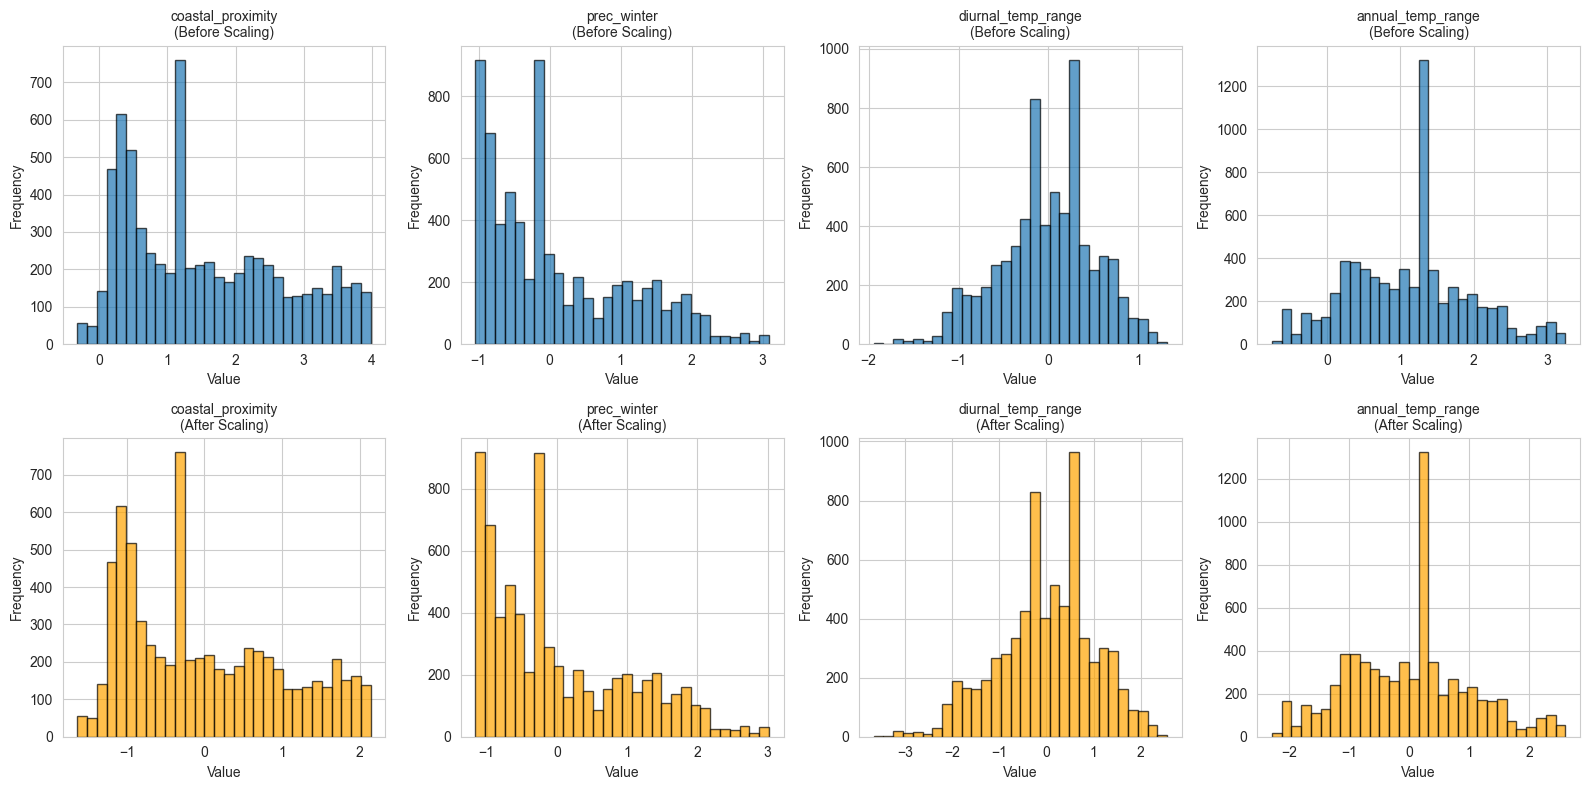

In [20]:
# Visualize distribution of a few features before and after scaling
sample_features = X_selected.columns[:4].tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, feature in enumerate(sample_features):
    # Before scaling
    axes[0, idx].hist(X_selected[feature], bins=30, edgecolor='black', alpha=0.7)
    axes[0, idx].set_title(f'{feature}\n(Before Scaling)', fontsize=10)
    axes[0, idx].set_xlabel('Value')
    axes[0, idx].set_ylabel('Frequency')
    
    # After scaling
    axes[1, idx].hist(X_scaled[feature], bins=30, edgecolor='black', alpha=0.7, color='orange')
    axes[1, idx].set_title(f'{feature}\n(After Scaling)', fontsize=10)
    axes[1, idx].set_xlabel('Value')
    axes[1, idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 5. Final Dataset Preparation

In [21]:
# Combine features with target and coordinates
final_dataset = pd.concat([
    df_engineered[['longitude', 'latitude', 'class']],
    X_scaled
], axis=1)

print(f"Final dataset shape: {final_dataset.shape}")
print(f"\nFeatures: {final_dataset.columns.tolist()[:10]} ... (showing first 10)")
print(f"\nClass distribution:")
print(final_dataset['class'].value_counts())
print(f"\nMissing values: {final_dataset.isnull().sum().sum()}")

Final dataset shape: (6933, 23)

Features: ['longitude', 'latitude', 'class', 'coastal_proximity', 'prec_winter', 'diurnal_temp_range', 'annual_temp_range', 'tmin_winter', 'tmax_summer', 'ph_carbon_interaction'] ... (showing first 10)

Class distribution:
class
1    3824
0    3109
Name: count, dtype: int64

Missing values: 0


In [22]:
# Display sample of final dataset
print("Sample of final engineered dataset:\n")
final_dataset.head(10)

Sample of final engineered dataset:



,longitude,latitude,class,coastal_proximity,prec_winter,diurnal_temp_range,annual_temp_range,tmin_winter,tmax_summer,ph_carbon_interaction,elevation,summer_heat_index,ORG_CARBON,TOTAL_N,tmin_autumn,SAND,fertility_index,tmax_winter,fine_fraction,PH_WATER,REF_BULK,CN_RATIO,CLAY
0,9.82563,36.81855,1,-1.194368,0.453162,-0.064974,-0.910408,0.759642,0.277737,1.298236,-1.013541,0.081242,-0.017423,0.441556,0.735948,-0.334847,-0.720159,0.525674,0.252141,-1.056807,-0.521812,0.001534,-0.407481
1,3.08190,35.80751,0,-0.306491,-0.180938,-0.287520,-0.917840,-0.458641,-0.559087,-0.549771,0.844825,-0.472395,-0.467553,-0.336512,-0.866374,-0.446408,-0.067940,-1.143759,0.633744,0.687472,1.031954,-0.758059,1.006819
2,7.24027,34.56991,1,0.780348,-0.988477,0.297491,0.660529,0.904826,2.234340,-1.015028,-0.727092,1.922709,-0.746303,-0.842256,1.445547,1.003896,0.569306,1.158233,-0.717205,0.687472,-0.965746,-0.758059,-0.831770
3,1.60481,35.55047,0,-0.080763,-0.069811,0.791712,0.621990,-0.591201,0.440286,0.701180,0.795111,0.300250,0.217966,0.402653,-1.011346,-1.004218,-0.757155,-0.889431,0.937363,0.438289,0.699005,0.001534,0.723959
4,6.76514,36.55581,1,-0.963635,1.536382,-0.644765,-1.099598,0.071596,-0.775818,0.701180,0.496825,-1.058578,0.217966,0.402653,-0.423828,-1.004218,-0.757155,-0.732922,0.937363,0.438289,0.699005,0.001534,0.723959
5,10.90887,33.60776,0,1.625291,-1.159436,0.511442,0.236448,-1.878920,-0.396538,-1.526992,-1.079827,0.715613,-0.769016,0.285943,-0.187295,0.334525,-0.424146,-0.282957,0.060579,1.061246,0.809988,0.001534,0.723959
6,3.13490,36.60116,1,-1.003460,0.750768,0.156813,0.263312,0.797516,-0.535005,0.701180,-0.942521,-0.372785,0.217966,0.402653,0.446004,-1.004218,-0.757155,1.145191,0.937363,0.438289,0.699005,0.001534,0.723959
7,3.84587,36.39551,1,-0.822862,0.949191,-0.446733,-1.101127,-0.117774,-0.113583,0.701180,0.309805,-0.437066,0.217966,0.402653,-0.179665,-1.004218,-0.757155,-0.609018,0.937363,0.438289,0.699005,0.001534,0.723959
8,1.63896,36.37794,0,-0.807432,0.548595,-0.286355,-0.787520,0.273591,0.133250,0.701180,0.241152,0.347332,0.217966,0.402653,-0.225446,-1.004218,-0.757155,-0.276436,0.937363,0.438289,0.699005,0.001534,0.723959
9,2.66485,35.50831,0,-0.043739,-0.408210,0.350726,-0.606911,-0.168273,-0.005218,-0.549771,0.574948,-0.172122,-0.467553,-0.336512,-0.568800,-0.446408,-0.067940,-0.543806,0.633744,0.687472,1.031954,-0.758059,1.006819


In [23]:
# Save the engineered dataset
output_path = '../results/fires_engineered_features.csv'
final_dataset.to_csv(output_path, index=False)
print(f"✅ Engineered dataset saved to: {output_path}")

✅ Engineered dataset saved to: ../results/fires_engineered_features.csv


In [24]:
# Save feature importance and selection results
feature_scores.to_csv('../results/feature_importance_scores.csv', index=False)
print("✅ Feature importance scores saved to: ../results/feature_importance_scores.csv")

# Save selected features list
with open('../results/selected_features.txt', 'w') as f:
    f.write("Selected Features for Model Training\n")
    f.write("="*50 + "\n\n")
    for i, feat in enumerate(selected_features, 1):
        f.write(f"{i}. {feat}\n")
print("✅ Selected features list saved to: ../results/selected_features.txt")

✅ Feature importance scores saved to: ../results/feature_importance_scores.csv
✅ Selected features list saved to: ../results/selected_features.txt
✅ Selected features list saved to: ../results/selected_features.txt


## 6. Summary

### Feature Engineering Pipeline Summary

**1. Feature Extraction:**
- Created 22 new features from domain knowledge
- Climate features: temperature ranges, precipitation patterns, drought indices
- Topography features: terrain complexity, aspect categories, slope interactions
- Soil features: composition ratios, fertility indices, moisture retention
- Spatial features: country indicators, coastal proximity

**2. Categorical Feature Encoding:**
- **TEXTURE_USDA**: Already numerical (normalized values) - treated as numerical
- **TEXTURE_SOTER**: One-hot encoded into binary columns
  - TEXTURE_SOTER_F (Fine texture indicator)
  - TEXTURE_SOTER_M (Medium texture indicator)
  - Baseline: TEXTURE_SOTER_C (Coarse texture, when both = 0)
  - Note: `drop_first=True` drops the first category alphabetically (C in this case)
- One-hot encoded features competed fairly with all numerical features

**3. Feature Selection (Multi-Step Process):**

**Step 1: One-Hot Encoding**
- Applied early to allow categorical features to participate in selection
- Created binary columns that can be correlated with target

**Step 2: Remove Multicollinearity (Feature-to-Feature)**
- Identified highly correlated feature pairs (correlation > 0.90)
- For each pair, kept the feature with higher target correlation
- Removed redundant features to reduce multicollinearity
- One-hot encoded features included in this analysis

**Step 3: Select Top 30 by Target Correlation**
- Calculated correlation between ALL features (including one-hot) and target
- Selected top 30 features with highest absolute correlation to fire occurrence
- One-hot encoded features competed on equal footing

**Step 4: Narrow to Top 20 with Additional Methods**
- Applied ANOVA F-test for statistical significance
- Applied Mutual Information for non-linear relationships
- Applied Random Forest for feature importance
- Combined all methods with composite scoring
- Selected final top 20 features (may include one-hot encoded features if they scored high)

**4. Feature Scaling:**
- Applied StandardScaler for Z-score normalization
- All features now have mean ≈ 0 and standard deviation ≈ 1
- Ensures fair comparison and better model performance
- One-hot encoded features also scaled for consistency

**Final Output:**
- Engineered dataset: rows × 23 columns (longitude, latitude, class + 20 selected features)
- Ready for machine learning model training
- All features scaled and properly encoded
- No missing values
- No multicollinearity issues
- One-hot encoded features competed fairly in selection process

In [25]:
print("\n" + "="*80)
print("FEATURE ENGINEERING COMPLETE")
print("="*80)
print(f"\n📊 Original dataset: {df.shape[0]} rows × {df.shape[1]} features")
print(f"📊 Final dataset: {final_dataset.shape[0]} rows × {final_dataset.shape[1]} columns")
print(f"\n✅ Feature Extraction: Created 22 new domain-specific features")
print(f"✅ Categorical Encoding: One-hot encoded TEXTURE_SOTER (created binary features)")
print(f"✅ Feature Selection: Selected top {len(selected_features)} most predictive features")
print(f"     - Multicollinearity removal (r > 0.90)")
print(f"     - Target correlation ranking (top 30)")
print(f"     - Composite scoring: ANOVA + MI + RF (top 20)")

# Check if one-hot features made it to final selection
one_hot_final = [col for col in selected_features if col.startswith('TEXTURE_SOTER_')]
if one_hot_final:
    print(f"✅ One-hot features in final selection: {one_hot_final}")
    print(f"     (Categorical feature competed successfully!)")
else:
    print(f"✅ No one-hot features in final selection")
    print(f"     (Categorical feature had lower predictive power)")

print(f"✅ Feature Scaling: StandardScaler applied (all features normalized)")
print(f"\n📁 Output file: {output_path}")
print(f"\n🎯 Dataset is ready for model training!")
print("="*80)


FEATURE ENGINEERING COMPLETE

📊 Original dataset: 6933 rows × 42 features
📊 Final dataset: 6933 rows × 23 columns

✅ Feature Extraction: Created 22 new domain-specific features
✅ Categorical Encoding: One-hot encoded TEXTURE_SOTER (created binary features)
✅ Feature Selection: Selected top 20 most predictive features
     - Multicollinearity removal (r > 0.90)
     - Target correlation ranking (top 30)
     - Composite scoring: ANOVA + MI + RF (top 20)
✅ No one-hot features in final selection
     (Categorical feature had lower predictive power)
✅ Feature Scaling: StandardScaler applied (all features normalized)

📁 Output file: ../results/fires_engineered_features.csv

🎯 Dataset is ready for model training!
